# KITScenes — HD map ml label generation and visualization demo

This notebook shows how to extract **ML-converter map labels** (Lanelet2 submaps)
along a scene ego trajectory using the public `kitscenes` API.

**Requirements:**
- Dataset mounted or extracted on disk (edit paths in the configuration cell)
- Lanelet2 wheel with `ml_converter` from `res/ml_converter_wheels/`
- `pip install -e ".[map,viz]"`

Figures are displayed inline in the notebook.

In [52]:
from __future__ import annotations

import tempfile

import cv2
import matplotlib.pyplot as plt

%matplotlib inline

from kitscenes import KITScenesDataset
from kitscenes.visualization.map_viz import (
    create_map_projector,
    default_car_img_path,
    generate_map_labels_for_scene,
    get_map_data_for_ego_pose,
    render_map_top_down,
)
from kitscenes.visualization.ml_converter_vis_utils import (
    TYPE_GROUPINGS,
    get_grouping_description,
)

## Configuration

Edit the paths and options below for your machine.

In [53]:
DATASET_ROOT = "/tmp/fehler/ratarmount/kitscenes"  # ratarmount or extracted dataset root
SPLIT = "val"
SCENE_ID = "c34c778f-ad8c-0aa9-7e1a-c86a73f887c7"  # None → first scene in split; or set a scene UUID string

TYPE_GROUPING = "default"  # "default", "road_border_merged", "maptr_simple", "m3tr"
FRAME_STEP = 5
MAX_FRAMES = None  # cap batch size for a quick run, e.g. 20

if TYPE_GROUPING not in TYPE_GROUPINGS:
    raise ValueError(
        f"Unknown TYPE_GROUPING {TYPE_GROUPING!r}. "
        f"Choose from: {sorted(TYPE_GROUPINGS)}"
    )

print("Dataset root:", DATASET_ROOT)
print("Available map type groupings:", sorted(TYPE_GROUPINGS.keys()))
print(get_grouping_description(TYPE_GROUPING))

Dataset root: /tmp/fehler/ratarmount/kitscenes
Available map type groupings: ['default', 'm3tr', 'maptr_simple', 'road_border_merged']
Each type in its own group (no merging)


## Load scene

In [54]:
ds = KITScenesDataset(root=DATASET_ROOT, split=SPLIT)
print(ds)

if not ds.scene_ids:
    raise RuntimeError(
        f"No scenes found for split={SPLIT!r}. Download scenes first "
        f"(see README: python -m kitscenes.download)."
    )

scene_id = SCENE_ID or ds.scene_ids[0]
if scene_id not in ds.scene_ids:
    raise ValueError(f"Scene {scene_id!r} not in split {SPLIT!r}")

scene = ds.get_scene(scene_id)
print(scene)
print(f"Frames: {scene.metadata.num_frames}, sensors: {scene.metadata.sensor_names[:5]}...")
print(f"Ego poses: {len(scene.ego_poses)}")

scene_map = scene.map
if scene_map is None:
    raise FileNotFoundError(f"No map under {scene.scene_path / 'maps'}")

KITScenesDataset(root=PosixPath('/tmp/fehler/ratarmount/kitscenes'), split='val', num_scenes=9)
Scene(scene_id='c34c778f-ad8c-0aa9-7e1a-c86a73f887c7', scene_path=PosixPath('/tmp/fehler/ratarmount/kitscenes/data/val/c34c778f-ad8c-0aa9-7e1a-c86a73f887c7'), timestamps_ns=array([   52000000,   152000000,   252000000,   352000000,   452000000,
         552000000,   652000000,   752000000,   852000000,   952000000,
        1052000000,  1152000000,  1252000000,  1352000000,  1452000000,
        1552000000,  1652000000,  1752000000,  1852000000,  1952000000,
        2052000000,  2152000000,  2252000000,  2352000000,  2452000000,
        2552000000,  2652000000,  2752000000,  2852000000,  2952000000,
        3052000000,  3152000000,  3252000000,  3352000000,  3452000000,
        3552000000,  3652000000,  3752000000,  3852000000,  3952000000,
        4051999999,  4152000000,  4252000000,  4352000000,  4452000000,
        4552000000,  4652000000,  4752000000,  4852000000,  4952000000,
        505

## Single-frame map label + visualization

Total labels: 297
Road borders (or similar): 110
Lane dividers: 116
Vehicle centerlines: 51
Bike centerlines: 8
Traffic elements: 203


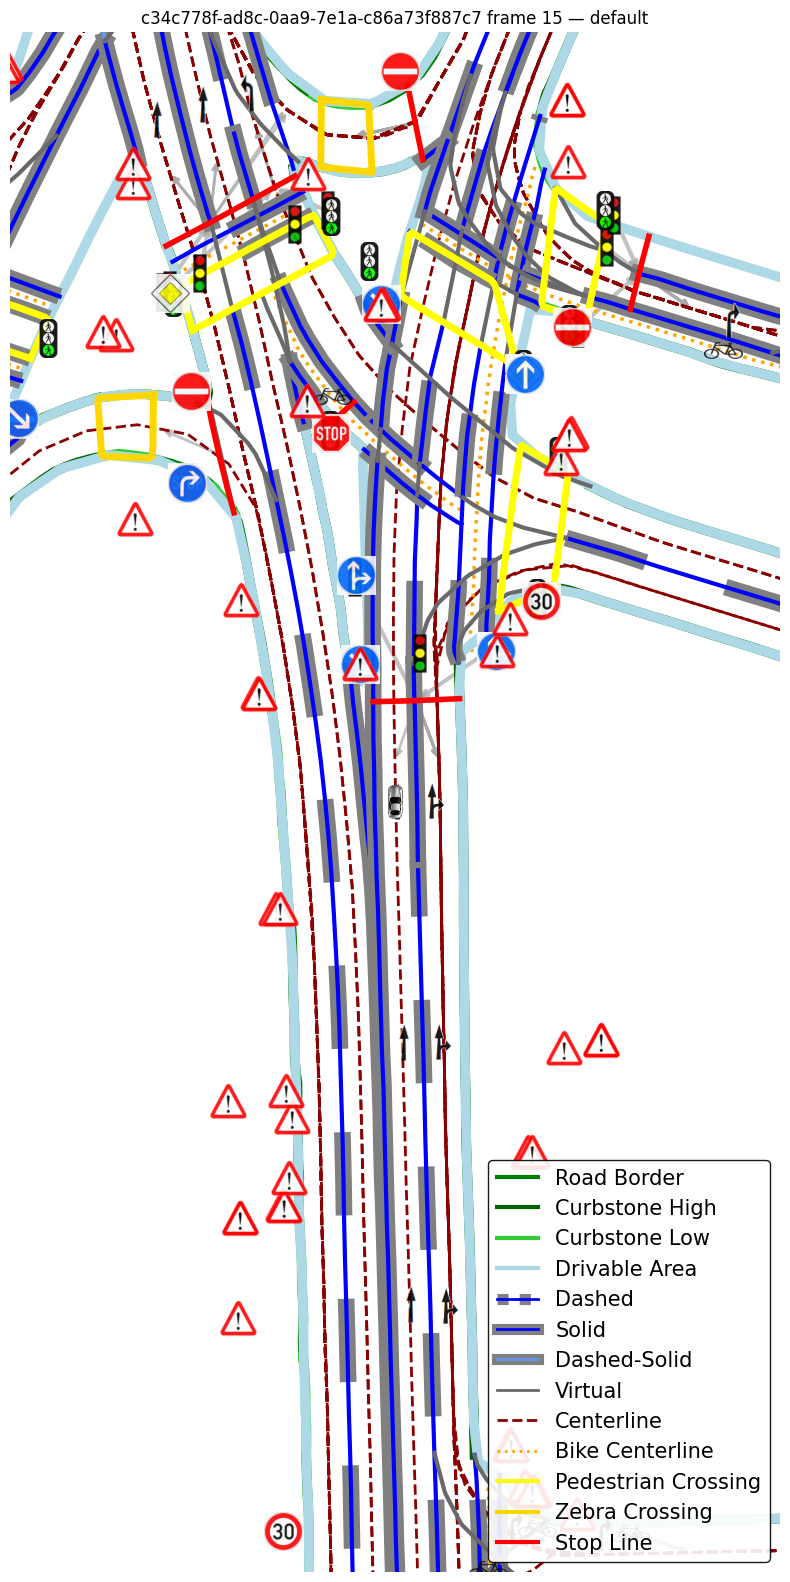

In [55]:
FRAME_IDX = 15
ego_pose = scene.ego_poses[FRAME_IDX]

m_data = get_map_data_for_ego_pose(
    scene_map,
    ego_pose,
    type_grouping=TYPE_GROUPING,
    ignore_map_ele=True,
)
if isinstance(m_data, str):
    raise RuntimeError(f"MapData extraction failed: {m_data}")

fig, ax = render_map_top_down(
    ego_pose,
    scene_map,
    type_grouping=TYPE_GROUPING,
    car_img_path=default_car_img_path(),
)
ax.set_title(f"{scene.scene_id} frame {FRAME_IDX} — {TYPE_GROUPING}")
plt.show()
plt.close(fig)

## Map projected onto `camera_ring_front`

Uses :func:`~kitscenes.visualization.map_viz.create_map_projector` with ``front_only=True`` (ML-converter map elements overlaid on the ring front camera). Projection writes to a temporary directory; only the rendered image is shown inline.

Loaded calibration from /tmp/fehler/ratarmount/kitscenes/data/val/c34c778f-ad8c-0aa9-7e1a-c86a73f887c7/calibration/calib.json
Pose/timestamp alignment: scale=1,shift_to_pose_start, unique mapped frames=220/220, median nearest error=0.000000s
Loaded 220 poses
Output directory: /tmp/kitscenes_map_proj_qetmsrp9
Loading map from /tmp/fehler/ratarmount/kitscenes/data/val/c34c778f-ad8c-0aa9-7e1a-c86a73f887c7/maps/map.osm
Malformed-map filter: 0 lanelet(s) with <=1 unique-point bounds, 0 associated boundary line string(s) marked for rebuild skipping
Successfully loaded lanelet2 map
  Lanelets: 529
Found 49 traffic sign linestrings with subtype='unknown' (will be hidden)


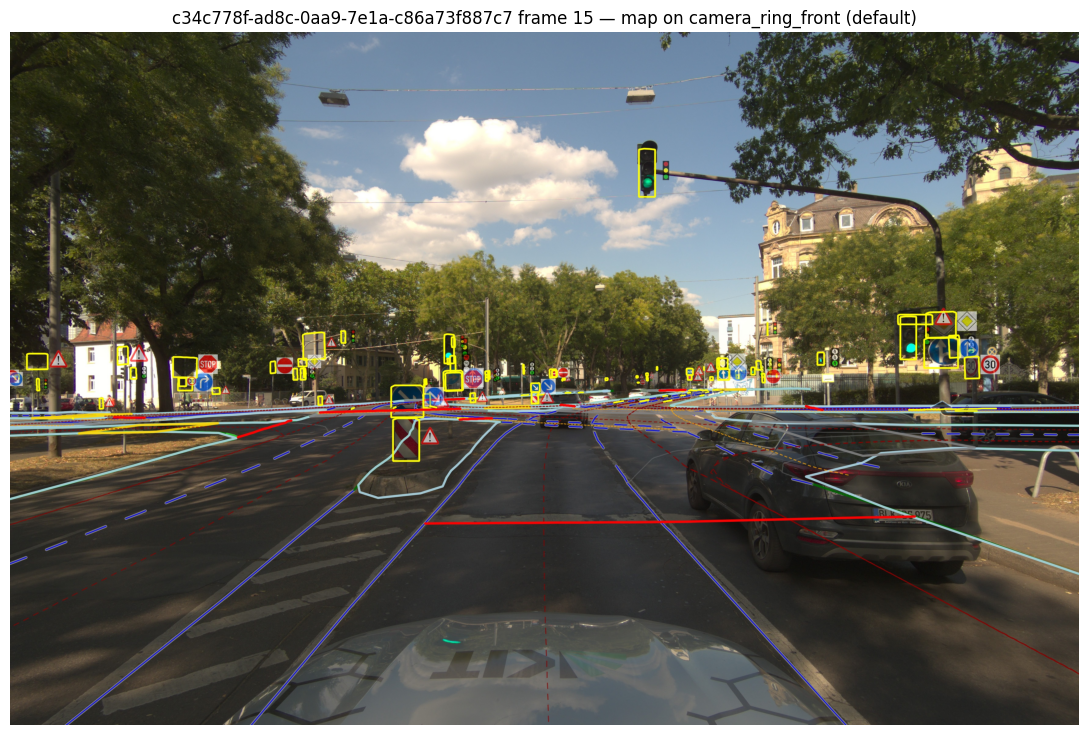

In [56]:
try:
    FRAME_IDX
except NameError:
    FRAME_IDX = 0

CAMERA_NAME = "camera_ring_front"

with tempfile.TemporaryDirectory(prefix="kitscenes_map_proj_") as tmp_out:
    projector = create_map_projector(
        scene.scene_path,
        tmp_out,
        type_grouping=TYPE_GROUPING,
        front_only=True,
        skip_top_down=True,
    )
    results = projector.project_frame(FRAME_IDX)

    cam_path = results.get(CAMERA_NAME)
    if cam_path is None:
        raise RuntimeError(
            f"No projection for {CAMERA_NAME!r} at frame {FRAME_IDX}. "
            f"Keys returned: {sorted(results)}"
        )

    img_bgr = cv2.imread(str(cam_path))
    if img_bgr is None:
        raise RuntimeError(f"Failed to read projection image: {cam_path}")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
fig, ax = plt.subplots(1, 1, figsize=(16, 9))
ax.imshow(img_rgb)
ax.axis("off")
ax.set_title(
    f"{scene.scene_id} frame {FRAME_IDX} — map on {CAMERA_NAME} ({TYPE_GROUPING})"
)
plt.show()
plt.close(fig)

## Batch map labels along the trajectory

`generate_map_labels_for_scene` walks the reference timeline and returns one
ML-converter `MapData` object per selected frame (same pipeline used for map-training tasks).

In [57]:
map_data_list, poses_used = generate_map_labels_for_scene(
    scene,
    type_grouping=TYPE_GROUPING,
    frame_step=FRAME_STEP,
    max_frames=MAX_FRAMES,
)

errors = [md for md in map_data_list if isinstance(md, str)]
print(f"Labels: {len(map_data_list)}, errors: {len(errors)}, poses: {len(poses_used)}")
if errors:
    print("Sample errors:", errors[:3])

Labels: 44, errors: 0, poses: 44


## Visualize these batch labels

Renders a few frames with `render_map_top_down`. Set `preview_indices = range(len(poses_used))` to display every batch label.

Total labels: 275
Road borders (or similar): 103
Lane dividers: 105
Vehicle centerlines: 49
Bike centerlines: 8
Traffic elements: 172


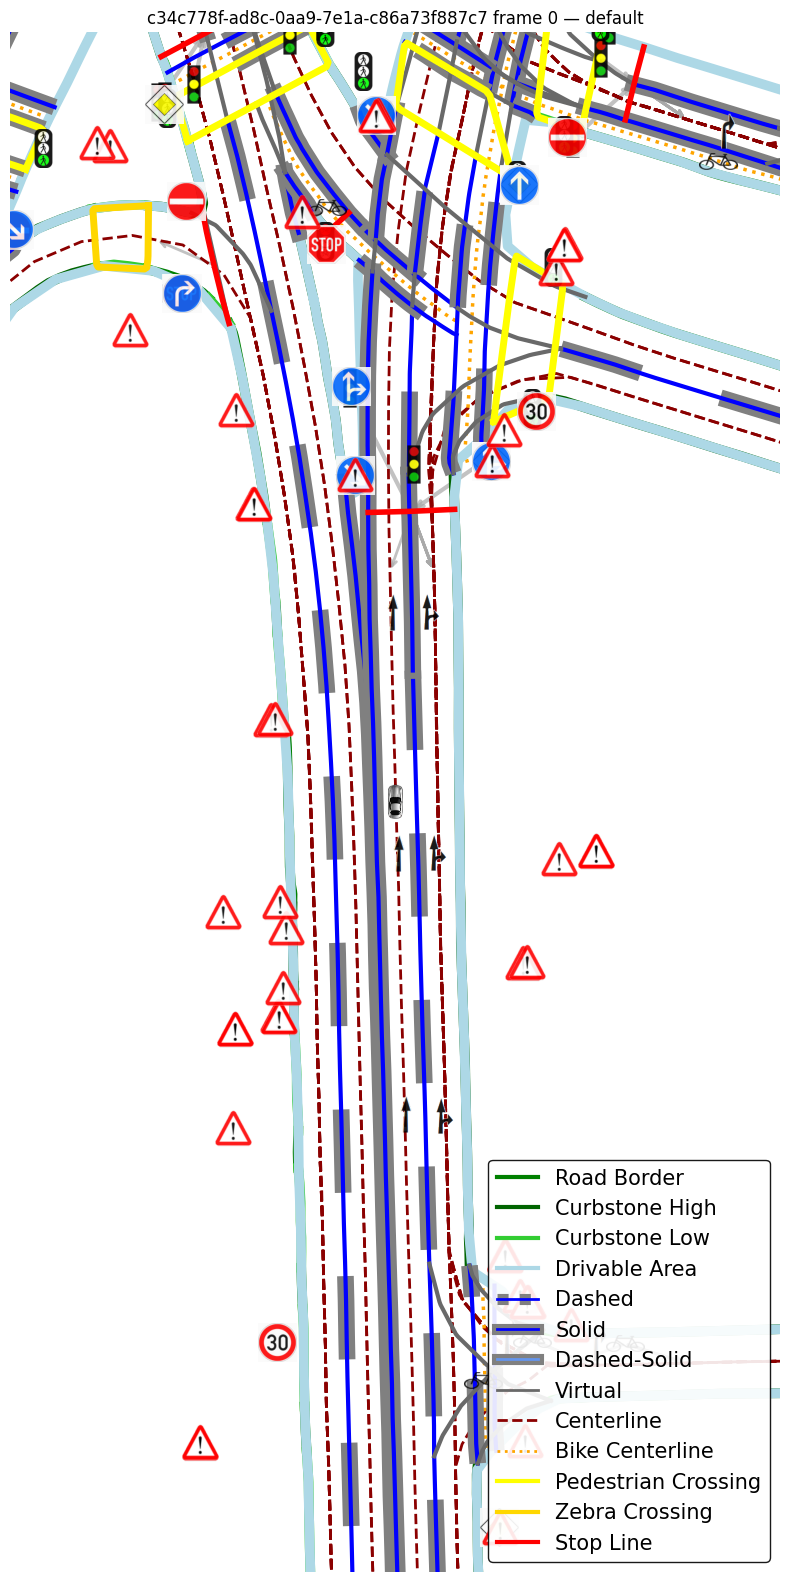

Total labels: 329
Road borders (or similar): 113
Lane dividers: 151
Vehicle centerlines: 43
Bike centerlines: 8
Traffic elements: 244


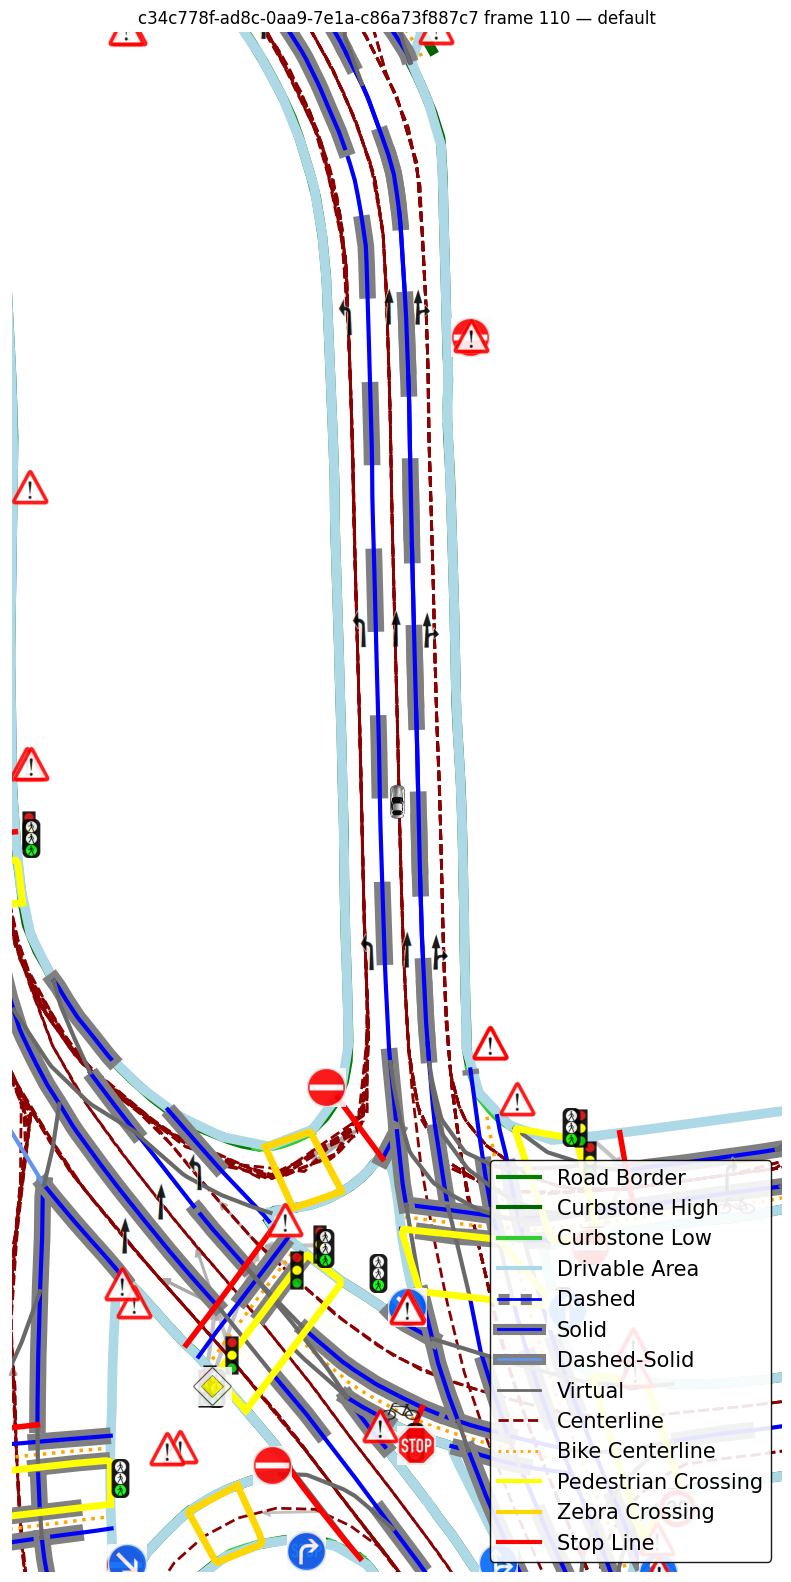

Total labels: 288
Road borders (or similar): 84
Lane dividers: 135
Vehicle centerlines: 50
Bike centerlines: 5
Traffic elements: 197


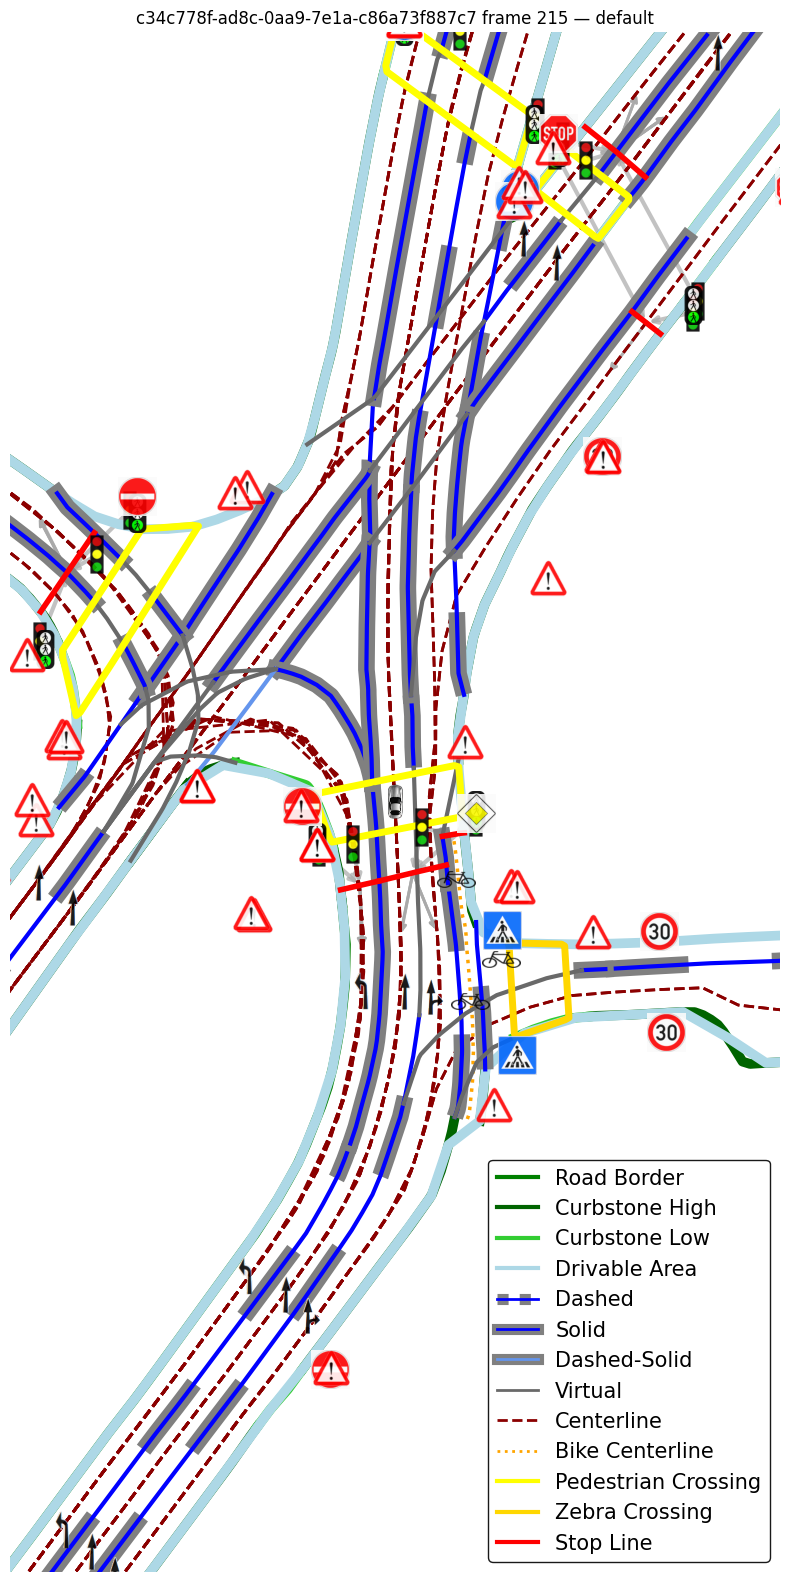

In [58]:
limit = min(scene.metadata.num_frames, len(scene.ego_poses))
label_frame_indices = list(range(0, limit, FRAME_STEP))
if MAX_FRAMES is not None:
    label_frame_indices = label_frame_indices[:MAX_FRAMES]

car_img = default_car_img_path()
preview_indices = [0, len(poses_used) // 2, len(poses_used) - 1]
preview_indices = sorted({i for i in preview_indices if 0 <= i < len(poses_used)})

for i in preview_indices:
    if isinstance(map_data_list[i], str):
        print(f"Label {i}: {map_data_list[i]}")
        continue

    frame_idx = label_frame_indices[i]
    ego_pose = poses_used[i]

    fig, ax = render_map_top_down(
        ego_pose,
        scene_map,
        type_grouping=TYPE_GROUPING,
        car_img_path=car_img,
    )
    ax.set_title(f"{scene.scene_id} frame {frame_idx} — {TYPE_GROUPING}")
    plt.show()
    plt.close(fig)